A extrair contexto histórico para SUZB3.SA...


/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


A extrair contexto histórico para VALE3.SA...


/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


A extrair contexto histórico para MGLU3.SA...
A extrair contexto histórico para LREN3.SA...


/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



A treinar a rede neural com os dados pré-crise...
Treino concluído!
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


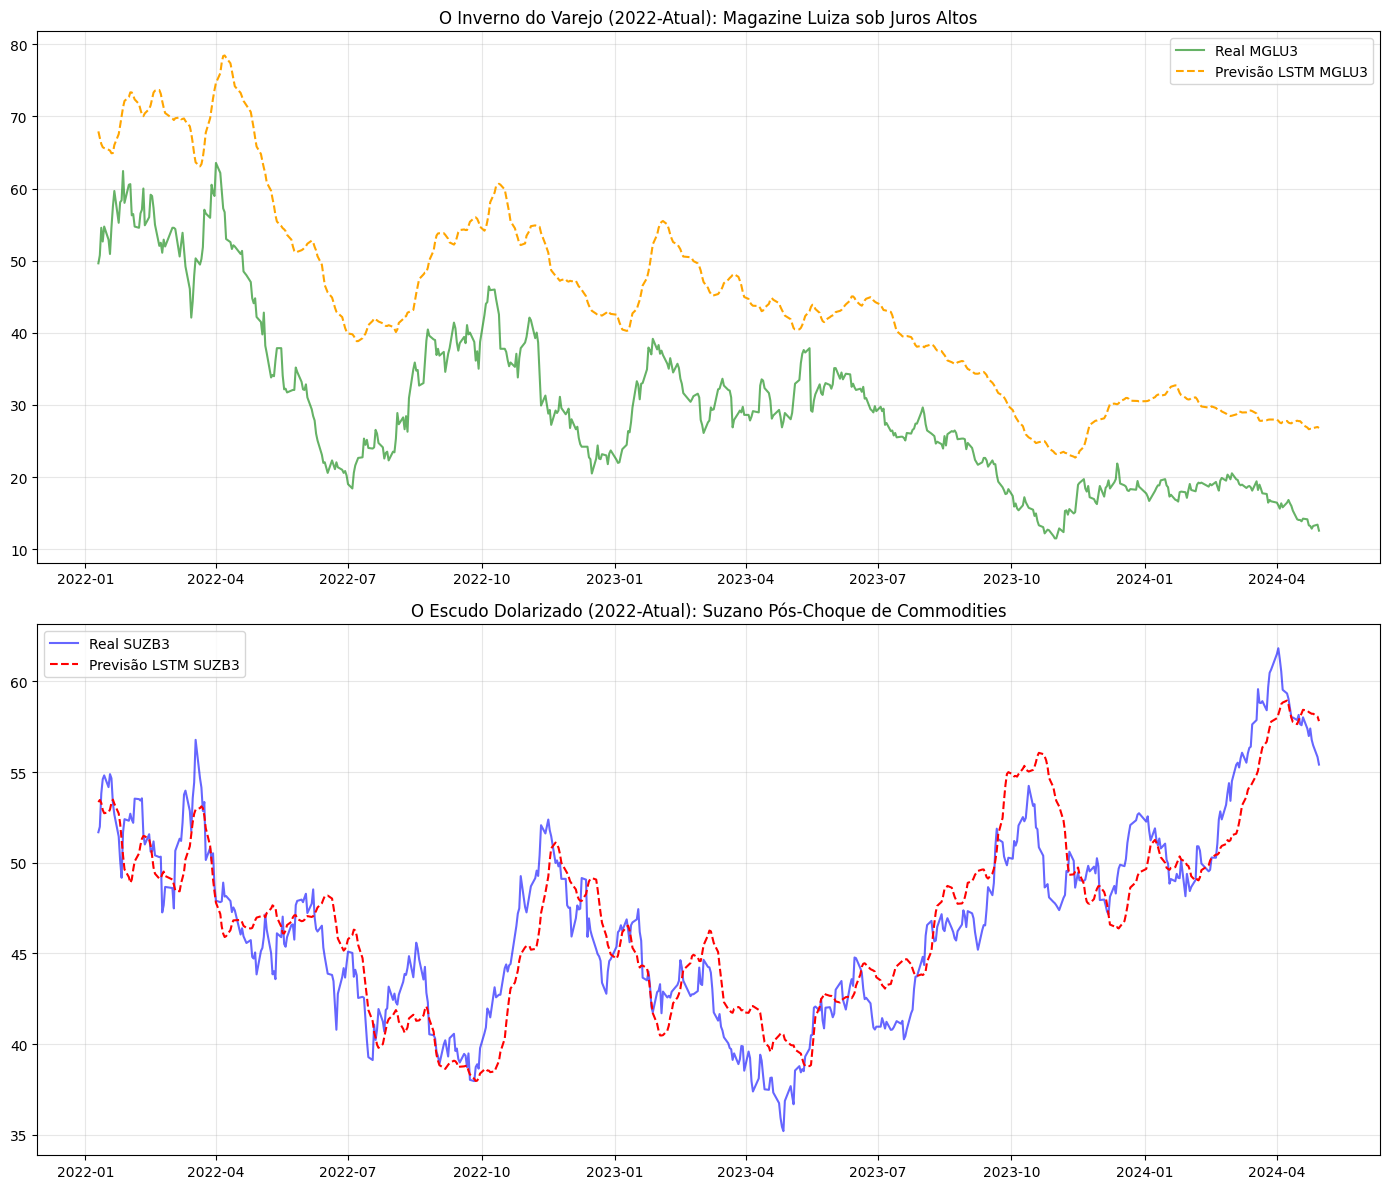

In [8]:
# ==============================================================================
# PROJETO: A Grande Divergência (Varejo vs Exportação) - LSTM Out-of-Sample
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

# 1. Parâmetros Históricos (Treino na Euforia, Teste na Crise/Atualidade)
tickers = ["SUZB3.SA", "VALE3.SA", "MGLU3.SA", "LREN3.SA"]
start_date = "2018-01-01"
split_date = "2022-01-01" # Ponto de ruptura: Início do aperto monetário forte
end_date = "2024-05-01"   # Momento atual

# 2. Recolha Segura de Dados e Features (Puro Pandas)
dfs = []
for ticker in tickers:
    print(f"A extrair contexto histórico para {ticker}...")
    acao = yf.Ticker(ticker)
    raw_data = acao.history(start=start_date, end=end_date)

    df = pd.DataFrame(raw_data['Close'])
    df.index = df.index.tz_localize(None)

    # Indicadores Técnicos
    df['SMA_5'] = df['Close'].rolling(window=5).mean()
    df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()

    # RSI Puro
    delta = df['Close'].diff()
    ganho = delta.where(delta > 0, 0.0)
    perda = -delta.where(delta < 0, 0.0)
    media_ganho = ganho.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    media_perda = perda.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    rs = media_ganho / media_perda
    df['RSI_14'] = 100 - (100 / (1 + rs))

    df.columns = [f'{ticker}_Close', f'{ticker}_SMA', f'{ticker}_EMA', f'{ticker}_RSI']
    dfs.append(df)

dataset = pd.concat(dfs, axis=1).dropna()

# 3. Divisão Histórica (Data Leakage Prevention)
# Treino: 2018 a final de 2021 | Teste (Previsão): 2022 até hoje
train_data_df = dataset[dataset.index < split_date]
test_data_df  = dataset[dataset.index >= split_date]

data_matrix_train = train_data_df.values
data_matrix_test  = test_data_df.values

# 4. Escalonamento Isolado (MinMaxScaler)
target_cols = [f'{t}_Close' for t in tickers]
target_indices = [dataset.columns.get_loc(c) for c in target_cols]

scaler_f = MinMaxScaler()
scaler_t = MinMaxScaler()

train_scaled = scaler_f.fit_transform(data_matrix_train)
test_scaled  = scaler_f.transform(data_matrix_test)

scaler_t.fit(data_matrix_train[:, target_indices])

# 5. Criação das Janelas Temporais (5 Dias)
def create_sequences(data, target_data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])
        y.append(target_data[i + window_size, :])
    return np.array(X), np.array(y)

window_size = 5

train_target_scaled = train_scaled[:, target_indices]
test_target_scaled  = test_scaled[:, target_indices]

X_train, y_train = create_sequences(train_scaled, train_target_scaled, window_size)
X_test, y_test   = create_sequences(test_scaled, test_target_scaled, window_size)

# 6. Arquitetura da Rede Neural (LSTM + GRU MIMO)
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(4, activation='linear') # 4 Saídas simultâneas
])

model.compile(optimizer='adam', loss='mse')

# Treino do Modelo (Aprendendo as regras macroeconómicas de 2018 a 2021)
print("\nA treinar a rede neural com os dados pré-crise...")
model.fit(X_train, y_train, epochs=40, batch_size=32, validation_split=0.1, shuffle=False, verbose=0)
print("Treino concluído!")

# 7. Previsão do Momento Atual (2022 - Hoje)
pred_scaled = model.predict(X_test)

pred_real = scaler_t.inverse_transform(pred_scaled)
y_test_real = scaler_t.inverse_transform(y_test)

datas_teste = test_data_df.index[window_size:]

resultados = pd.DataFrame({
    'Data': datas_teste,
    'Real_SUZB': y_test_real[:, 0], 'Pred_SUZB': pred_real[:, 0],
    'Real_VALE': y_test_real[:, 1], 'Pred_VALE': pred_real[:, 1],
    'Real_MGLU': y_test_real[:, 2], 'Pred_MGLU': pred_real[:, 2],
    'Real_LREN': y_test_real[:, 3], 'Pred_LREN': pred_real[:, 3]
}).set_index('Data')

# 8. Gráficos Comprobatórios do Momento Histórico
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Gráfico 1: O Colapso do Varejo (Magalu)
ax1.plot(resultados.index, resultados['Real_MGLU'], label='Real MGLU3', color='green', alpha=0.6)
ax1.plot(resultados.index, resultados['Pred_MGLU'], label='Previsão LSTM MGLU3', color='orange', linestyle='dashed')
ax1.set_title('O Inverno do Varejo (2022-Atual): Magazine Luiza sob Juros Altos')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: A Resiliência Dolarizada (Suzano)
ax2.plot(resultados.index, resultados['Real_SUZB'], label='Real SUZB3', color='blue', alpha=0.6)
ax2.plot(resultados.index, resultados['Pred_SUZB'], label='Previsão LSTM SUZB3', color='red', linestyle='dashed')
ax2.set_title('O Escudo Dolarizado (2022-Atual): Suzano Pós-Choque de Commodities')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

A extrair dados e calcular Retornos Diários...


/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4War


A treinar a IA na variação percentual (O que elimina a quebra de escala)...
Treino concluído!
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

AVALIAÇÃO DE PRECISÃO (R2 SCORE) - PERÍODO ATÉ FINAL DE 2025
R2 Score Corrigido para SUZB3.SA: 0.9582
R2 Score Corrigido para VALE3.SA: 0.9738
R2 Score Corrigido para MGLU3.SA: 0.9857
R2 Score Corrigido para LREN3.SA: 0.9656


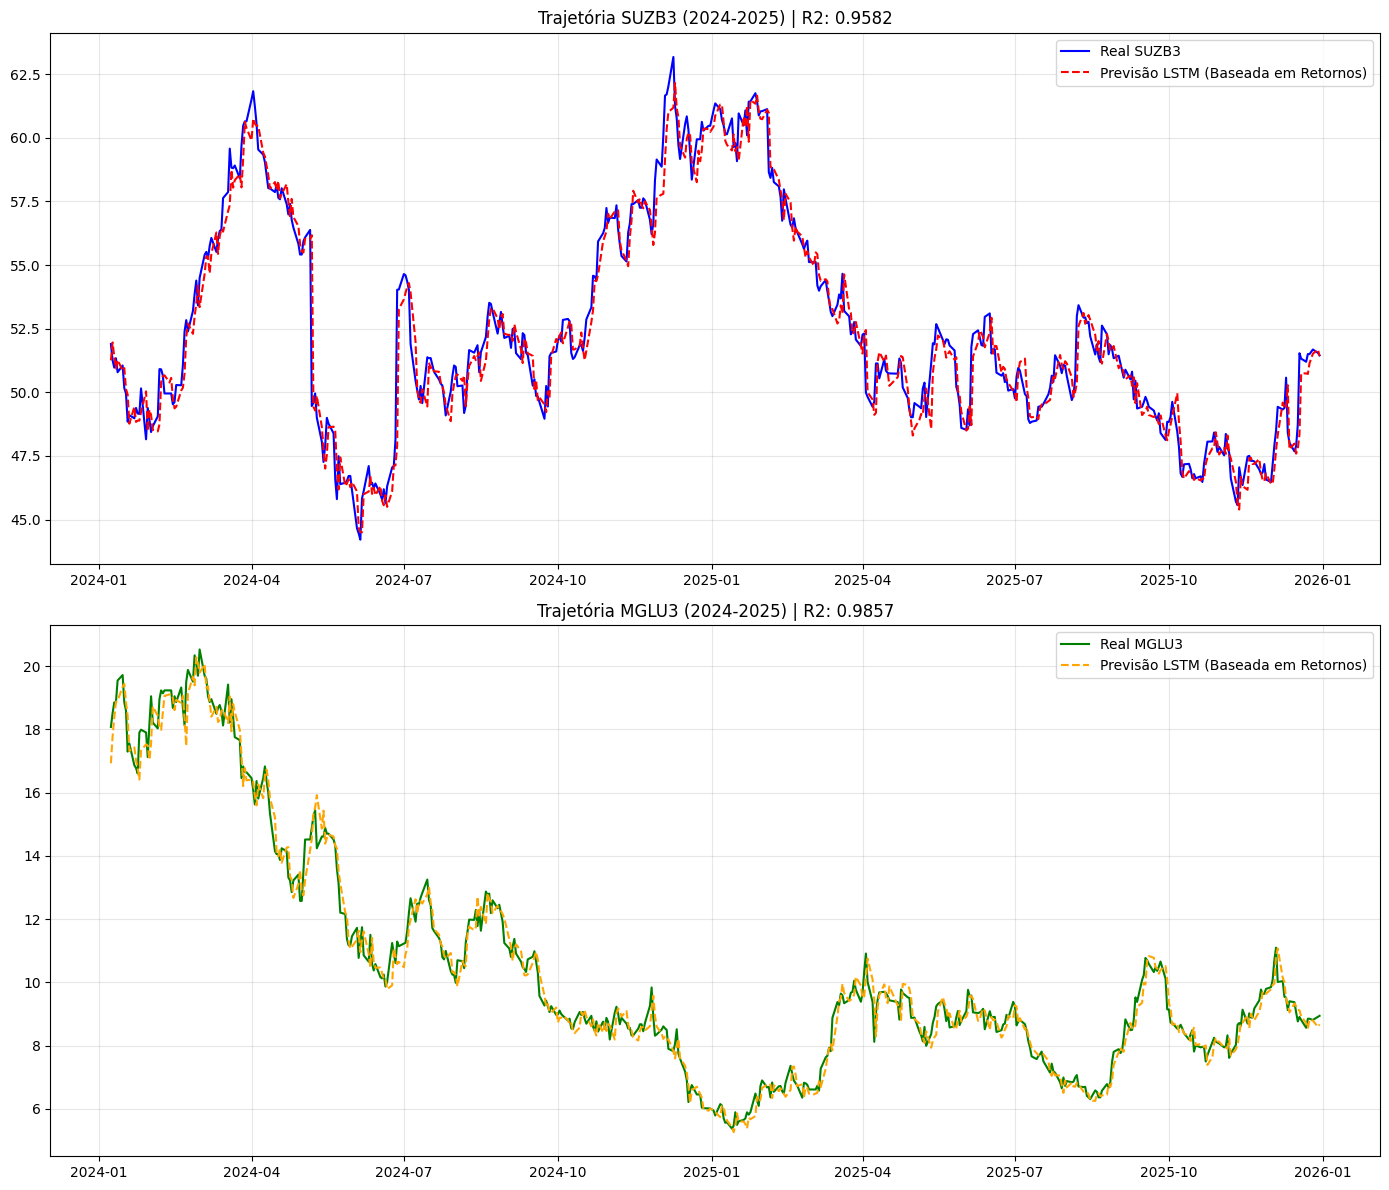

In [14]:
# ==============================================================================
# PROJETO: Previsão de Retornos Diários (A Solução Definitiva para Crashes)
# PERÍODO: Treino (2021-2023) | Teste (2024 - Final de 2025)
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

# 1. Definição do Período (Ajustado até final de 2025)
tickers_alvo = ["SUZB3.SA", "VALE3.SA", "MGLU3.SA", "LREN3.SA"]
tickers_macro = ["BRL=X", "^BVSP"]

start_date = "2021-01-01"
split_date = "2024-01-01"
end_date = "2025-12-31" # <-- Limite imposto

# 2. Extração de Dados (Foco apenas no Fechamento para calcular Retornos)
print("A extrair dados e calcular Retornos Diários...")
dfs_precos = []

for ticker in tickers_alvo + tickers_macro:
    acao = yf.Ticker(ticker)
    df = pd.DataFrame(acao.history(start=start_date, end=end_date)['Close'])
    df.index = df.index.tz_localize(None)
    df.columns = [ticker]
    dfs_precos.append(df)

# Junta tudo e preenche feriados
df_precos = pd.concat(dfs_precos, axis=1).ffill().dropna()

# ==============================================================================
# A MÁGICA MATEMÁTICA: LOG RETURNS (Retornos Percentuais Diários)
# ==============================================================================
# Em vez de prever R$ 2.00, a IA vai prever que a ação vai subir 0.5% hoje.
df_returns = np.log(df_precos / df_precos.shift(1)).dropna()

# 3. Divisão Treino/Teste
train_ret = df_returns[df_returns.index < split_date]
test_ret  = df_returns[df_returns.index >= split_date]

# 4. Normalização dos Retornos
scaler_f = StandardScaler()
scaler_t = StandardScaler() # Target scaler (apenas para as 4 ações alvo)

train_scaled = scaler_f.fit_transform(train_ret)
test_scaled  = scaler_f.transform(test_ret)

# Índices das ações alvo (os 4 primeiros)
target_indices = [df_returns.columns.get_loc(t) for t in tickers_alvo]
scaler_t.fit(train_ret.iloc[:, target_indices])

# 5. Janelas Temporais (Olha 5 dias de retornos para prever o próximo)
def create_sequences(data, target_data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])
        y.append(target_data[i + window_size, :])
    return np.array(X), np.array(y)

window_size = 5

train_target = train_scaled[:, target_indices]
test_target  = test_scaled[:, target_indices]

X_train, y_train = create_sequences(train_scaled, train_target, window_size)
X_test, y_test   = create_sequences(test_scaled, test_target, window_size)

# 6. Arquitetura da Rede Neural
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(4, activation='linear')
])

model.compile(optimizer='adam', loss='mse')

print("\nA treinar a IA na variação percentual (O que elimina a quebra de escala)...")
model.fit(X_train, y_train, epochs=40, batch_size=32, validation_split=0.1, shuffle=False, verbose=0)
print("Treino concluído!")

# 7. Previsão dos Retornos
pred_ret_scaled = model.predict(X_test)

# Reverte a escala para obter o retorno real (em decimal)
pred_ret_real = scaler_t.inverse_transform(pred_ret_scaled)
y_test_ret_real = scaler_t.inverse_transform(y_test)

# ==============================================================================
# RECONSTRUÇÃO DO PREÇO (1-Step Ahead)
# Preço_Previsto = Preço_Real_de_Ontem * exp(Retorno_Previsto_Pela_IA)
# ==============================================================================
# Pegamos os preços reais do período de teste
precos_reais_teste = df_precos[df_precos.index >= split_date].iloc[window_size:, target_indices].values
precos_reais_ontem = df_precos[df_precos.index >= split_date].iloc[window_size-1:-1, target_indices].values

precos_previstos = precos_reais_ontem * np.exp(pred_ret_real)

# 8. NOVO CÁLCULO DE R2 SCORE (Nos Preços Reconstruídos)
print("\n" + "="*50)
print("AVALIAÇÃO DE PRECISÃO (R2 SCORE) - PERÍODO ATÉ FINAL DE 2025")
print("="*50)

r2_scores = {}
for i, ticker in enumerate(tickers_alvo):
    r2 = r2_score(precos_reais_teste[:, i], precos_previstos[:, i])
    r2_scores[ticker] = r2
    print(f"R2 Score Corrigido para {ticker}: {r2:.4f}")
print("="*50)

# 9. Gráficos Comparativos (Suzano e Magalu)
datas_teste = test_ret.index[window_size:]

resultados = pd.DataFrame({
    'Data': datas_teste,
    'Real_SUZB': precos_reais_teste[:, 0], 'Pred_SUZB': precos_previstos[:, 0],
    'Real_MGLU': precos_reais_teste[:, 2], 'Pred_MGLU': precos_previstos[:, 2],
}).set_index('Data')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

ax1.plot(resultados.index, resultados['Real_SUZB'], label='Real SUZB3', color='blue')
ax1.plot(resultados.index, resultados['Pred_SUZB'], label='Previsão LSTM (Baseada em Retornos)', color='red', linestyle='dashed')
ax1.set_title(f'Trajetória SUZB3 (2024-2025) | R2: {r2_scores["SUZB3.SA"]:.4f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(resultados.index, resultados['Real_MGLU'], label='Real MGLU3', color='green')
ax2.plot(resultados.index, resultados['Pred_MGLU'], label='Previsão LSTM (Baseada em Retornos)', color='orange', linestyle='dashed')
ax2.set_title(f'Trajetória MGLU3 (2024-2025) | R2: {r2_scores["MGLU3.SA"]:.4f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()